In [1]:
!date

Tue Dec 10 10:17:49 AM CET 2024


In [9]:
import functools
from lexical_benchmark.stats import lexical_benchmark
from lexical_benchmark.utils import ipython_utils
from lexical_benchmark import settings
import pandas as pd

lm_df = lexical_benchmark.LexicalBenchmark.load(root_dir=settings.PATH.analysis_dir)

- ADJ: adjective
- ADP: adposition
- ADV: adverb
- AUX: auxiliary
- CCONJ: coordinating conjunction
- DET: determiner
- INTJ: interjection
- NOUN: noun
- NUM: numeral
- PART: particle
- PRON: pronoun
- PROPN: proper noun
- PUNCT: punctuation
- SCONJ: subordinating conjunction
- SYM: symbol
- VERB: verb
- X: other


In [7]:
from IPython.display import display, HTML

dtypes = {"freq": "int32", "POS": "string"}

stela_pos = lm_df.items.stela.groupby('POS')['freq'].sum().reset_index()
stela_pos = stela_pos.astype(dtypes)
stela_pos.to_csv(settings.PATH.analysis_dir / "wfp/stela_pos.csv", index=False, sep=";")
#stela_pos = stela_pos.sort_values('freq', ascending=False)


childes_pos = lm_df.items.childes.groupby('POS')['freq'].sum().reset_index()
childes_pos = childes_pos.astype(dtypes)
childes_pos.to_csv(settings.PATH.analysis_dir / "wfp/childes_pos.csv", index=False, sep=";")
#childes_pos = childes_pos.sort_values('freq', ascending=False)

word_cdi_pos = lm_df.items.word_cdi.groupby('POS')['freq'].sum().reset_index()
word_cdi_pos = word_cdi_pos.astype(dtypes)
word_cdi_pos.to_csv(settings.PATH.analysis_dir / "wfp/word_cdi_pos.csv", index=False, sep=";")
#word_cdi_pos = word_cdi_pos.sort_values('freq', ascending=False)


combined_html = ipython_utils.HTML_3_DF_HTML_TEMPLATE.format(
    title1="STELA/EN/3200h",
    table1=stela_pos.to_html(),
    title2="CHILDES/EN/Adult",
    table2=childes_pos.to_html(),
    title3="WORDBANK-CDI/EN-NA/Produce",
    table3=word_cdi_pos.to_html(),
)

display(HTML(combined_html))

,POS,freq
0,ADJ,2781867
1,ADP,5555177
2,ADV,2090416
3,AUX,1965757
4,CCONJ,1904311
5,DET,1
6,INTJ,1977468
7,NOUN,7651134
8,NUM,1138375
9,PART,265294


In [ ]:
adult_3200h_wf = adult_3200h_wf.sort_values('freq', ascending=False)
childes_adult_wf = childes_adult_wf.sort_values('freq', ascending=False)

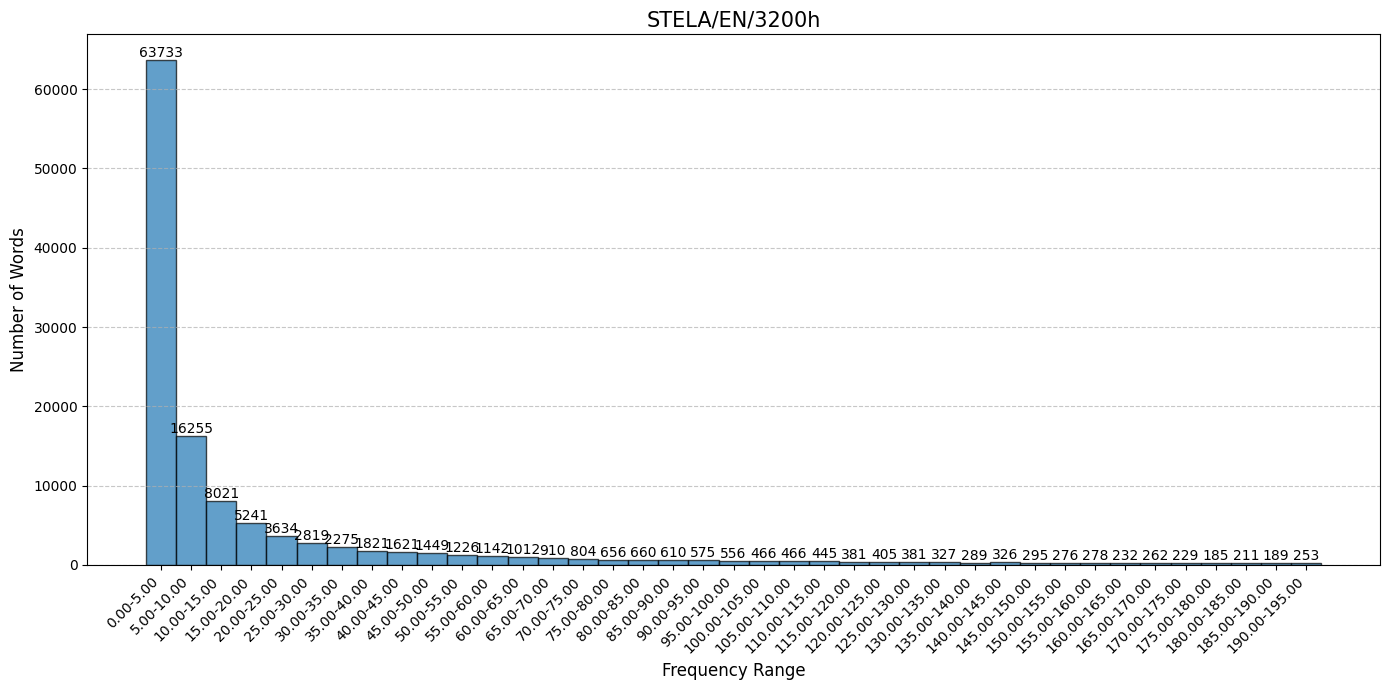

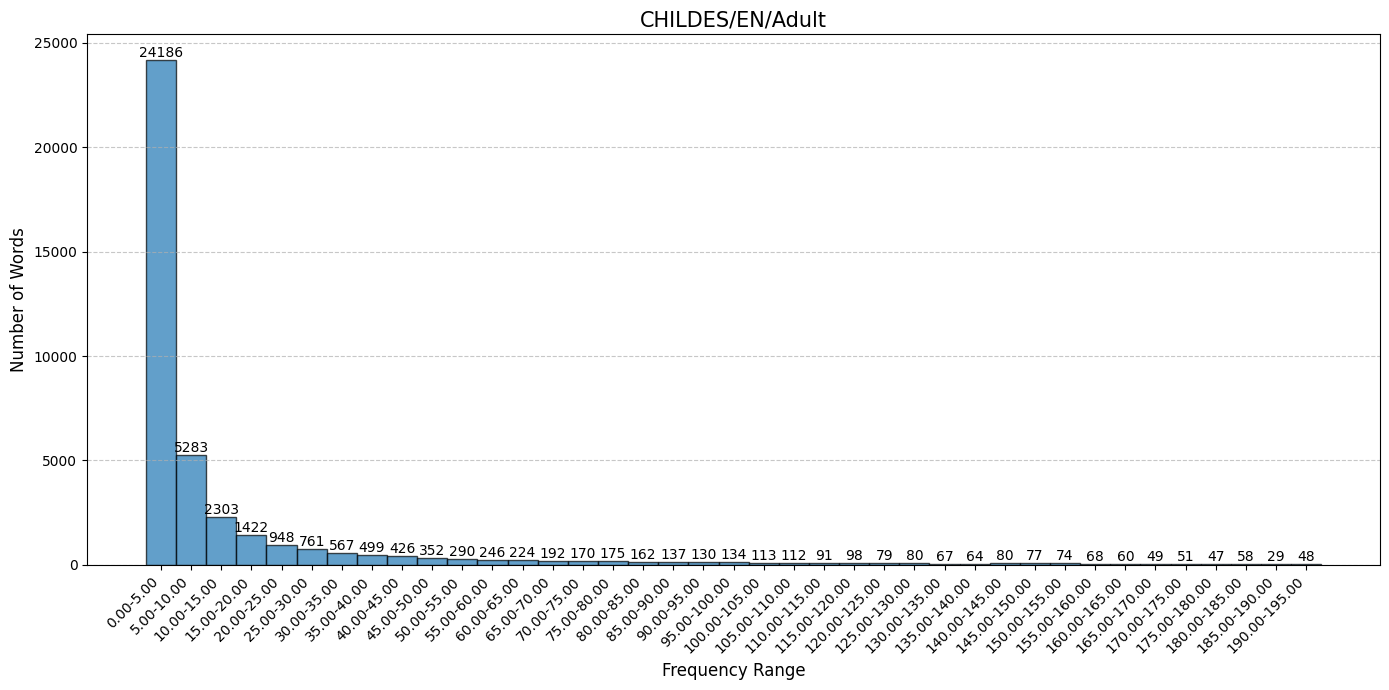

In [64]:
# Create and show the plot
custom_bins = list(range(0, 200, 5))
plot = plot_frequency_histogram(adult_3200h_wf, title="STELA/EN/3200h", bin_strategy="custom", custom_bins=custom_bins)
plot.show()

plot = plot_frequency_histogram(childes_adult_wf, title="CHILDES/EN/Adult", bin_strategy="custom", custom_bins=custom_bins)
plot.show()

In [21]:
import numpy as np
lm_df.items.stela[lm_df.items.stela["word"].isna()]

,word,freq,POS
30278,NaN,34,NaN
71718,NaN,103,NaN


In [24]:
from lexical_benchmark.datasets import childes
childes_dataset = childes.CHILDESDataset()
childes_na_adult_wf = childes_dataset.word_frequencies(lang_accent="Eng-NA", speech_type="adult", word_type="clean")
childes_uk_adult_wf = childes_dataset.word_frequencies(lang_accent="Eng-UK", speech_type="adult", word_type="clean")
childes_adult_wf = childes_na_adult_wf + childes_uk_adult_wf

In [29]:
childes_adult_wf["mommy"]

14150